# Notebook 9 — Class Weights — Tous modèles — 256×256

|                      |                                                                                                             |
| -------------------- | ----------------------------------------------------------------------------------------------------------- |
| **Objectif**         | Pondération des classes par fréquence médiane pour améliorer l'IoU des classes rares (human, object)        |
| **Résolution**       | 256 × 256                                                                                                   |
| **Protocole**        | **Strictement identique** aux notebooks 3/4/5/6 — imports depuis `scripts/`, mêmes modèles, mêmes callbacks |
| **Seule différence** | La loss CE+Dice est pondérée par classe (`make_weighted_loss`)                                              |
| **Mode**             | `WEIGHT_MODE = "median_freq"` (recommandé) ou `"custom"`                                                    |


In [3]:
# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
# os.environ["XLA_FLAGS"] = "--xla_gpu_strict_conv_algorithm_picker=false"
# os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"
# os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

os.environ["TF_USE_CUDNN_AUTOTUNE"] = "0"
os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"

# "1" si PB.
os.environ["TF_CUDNN_USE_FRONTEND"] = "0"

# Désactive le XLA auto-jit
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"

In [4]:
import tensorflow as tf

tf.config.optimizer.set_jit(False)
tf.config.experimental.enable_op_determinism()

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

if gpus:
    tf.config.set_logical_device_configuration(
        gpus[0], [tf.config.LogicalDeviceConfiguration(memory_limit=9000)]
    )

print("TF:", tf.__version__)

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF: 2.20.0


In [ ]:
import sys, gc, json, time, random
os.environ["XLA_FLAGS"] = "--xla_gpu_unsafe_fallback_to_driver_on_ptxas_not_found"

from pathlib import Path

ROOT = Path(".").resolve()
while not (ROOT / "scripts").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


from tensorflow.keras import backend as K
from tensorflow.keras import callbacks
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

from scripts.config        import ensure_dirs, resolve_split_csv, CITYSCAPES_DIR, EXP_DIR
from scripts.preprocessing import (CATEGORY_NAMES, N_CLASSES, IGNORE_LABEL,
                                   PALETTE, colorize_groups, overlay)
from scripts.datagen       import CityscapesSequence
from scripts.augmentations import make_train_aug
from scripts.losses_metrics import MeanIoUArgmax, dice_loss_sparse
from scripts.models        import (unet_scratch, unet_vgg16, unet_resnet50,
                                   unet_convnext_tiny, segformer_mitb0)

ensure_dirs()

print(f"Python     : {sys.version.split()[0]}")
print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {[g.name for g in tf.config.list_physical_devices('GPU')]}")


ROOT = /home/ui/PROJ9
Python     : 3.12.3
TensorFlow : 2.20.0
GPU        : ['/physical_device:GPU:0']


I0000 00:00:1773111639.609146 1425228 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9000 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080 Ti, pci bus id: 0000:07:00.0, compute capability: 6.1


In [ ]:
SEED       = 42
SIZE_HW    = (256, 256)
BATCH_SIZE = 4
EPOCHS     = 40
EPOCHS_FT  = 30
PATIENCE   = 8
AUG        = True

WEIGHT_MODE    = "median_freq"

CUSTOM_WEIGHTS = {
    "void"        : 0.1,
    "flat"        : 0.09,
    "construction": 0.16,
    "object"      : 3.5,
    "nature"      : 0.25,
    "sky"         : 1.0,
    "human"       : 4.0,
    "vehicle"     : 0.5,
}

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

SPLIT_CSV = resolve_split_csv()
df        = pd.read_csv(SPLIT_CSV)
train_df  = df[df["split_final"] == "train"].reset_index(drop=True)
val_df    = df[df["split_final"] == "val"].reset_index(drop=True)
test_df   = df[df["split_final"] == "test"].reset_index(drop=True)
print(f"Train : {len(train_df)}  |  Val : {len(val_df)}  |  Test : {len(test_df)}")
print(f"CITYSCAPES_DIR : {CITYSCAPES_DIR}")
print(f"EXP_DIR        : {EXP_DIR}")


Train : 2380  |  Val : 500  |  Test : 595
CITYSCAPES_DIR : /home/ui/PROJ9/data/raw/cityscapes
EXP_DIR        : /home/ui/PROJ9/out/experiments


## 1. Calcul des poids de classe


In [ ]:
from scripts.preprocessing import load_mask_labelids, remap_to_groups
from PIL import Image as PILImage

def _resolve(row, base, ca, cr):
    v = row.get(ca, "")
    return v if isinstance(v, str) and v else f"{base}/{row[cr]}"

print("Comptage des pixels par classe (train set)...")
pixel_counts = np.zeros(N_CLASSES, dtype=np.int64)
t0 = time.time()
for idx, row in train_df.iterrows():
    path = _resolve(row, str(CITYSCAPES_DIR), "mask_path", "mask_rel")
    arr  = np.array(remap_to_groups(load_mask_labelids(path)), dtype=np.uint8)
    for c in range(N_CLASSES):
        pixel_counts[c] += int((arr == c).sum())
    if idx % 300 == 0:
        print(f"  {idx}/{len(train_df)}...", end="\r")
print(f"\nTerminé en {time.time()-t0:.0f}s")

total_valid  = pixel_counts[1:].sum()
frequencies  = np.zeros(N_CLASSES, dtype=np.float64)
frequencies[1:] = pixel_counts[1:] / total_valid

if WEIGHT_MODE == "median_freq":
    median_freq   = np.median(frequencies[1:])
    raw_weights   = np.where(frequencies[1:] > 0,
                             median_freq / frequencies[1:], 0.0)
    raw_weights   = raw_weights / raw_weights.mean()
    class_weights = np.zeros(N_CLASSES, dtype=np.float32)
    class_weights[1:] = raw_weights.astype(np.float32)
    class_weights[0]  = 0.1
else:
    class_weights = np.array(
        [CUSTOM_WEIGHTS[n] for n in CATEGORY_NAMES], dtype=np.float32)

print(f"\nMode : {WEIGHT_MODE}")
print(f"{'Classe':<15} {'Pixels':>14} {'Fréq %':>8} {'Poids':>8}")
print("─" * 52)
for i, name in enumerate(CATEGORY_NAMES):
    print(f"{name:<15} {pixel_counts[i]:>14,} "
          f"{frequencies[i]*100:>7.2f}%  {class_weights[i]:>7.3f}")


Comptage des pixels par classe (train set)...
  2100/2380...
Terminé en 41s

Mode : median_freq
Classe                  Pixels   Fréq %    Poids
────────────────────────────────────────────────────
void               452,629,505    0.00%    0.100
flat             2,001,048,482   44.09%    0.089
construction     1,095,804,963   24.14%    0.162
object              87,749,755    1.93%    2.021
nature             747,803,175   16.48%    0.237
sky                177,566,814    3.91%    0.999
human               58,848,462    1.30%    3.013
vehicle            369,770,604    8.15%    0.480


/tmp/ipykernel_1425228/1285173257.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(CATEGORY_NAMES, rotation=30, ha="right")
/tmp/ipykernel_1425228/1285173257.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(CATEGORY_NAMES, rotation=30, ha="right")


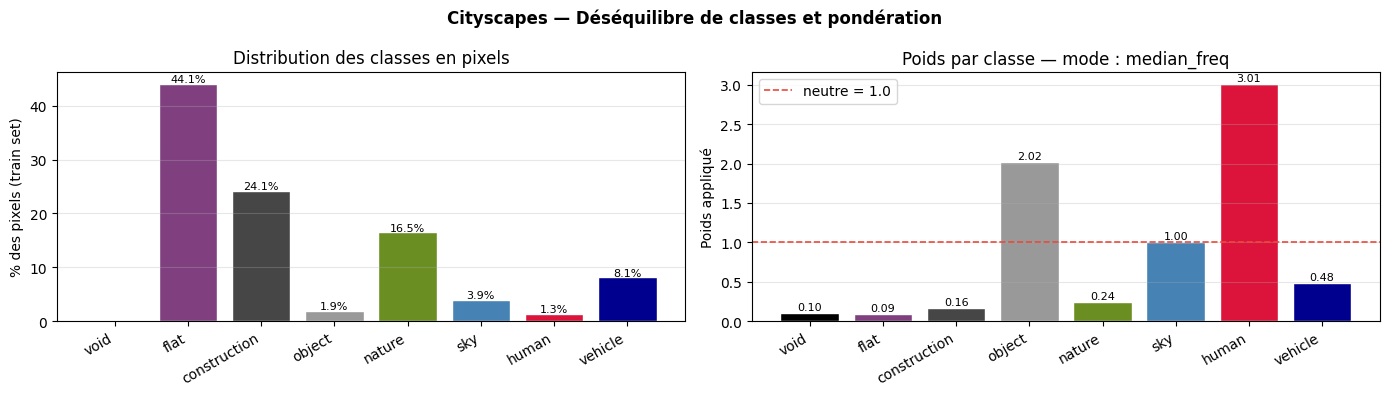

In [8]:
colors_norm = [tuple(c/255 for c in PALETTE[i]) for i in range(N_CLASSES)]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(CATEGORY_NAMES, frequencies*100, color=colors_norm, edgecolor="white")
axes[0].set_ylabel("% des pixels (train set)")
axes[0].set_title("Distribution des classes en pixels")
axes[0].set_xticklabels(CATEGORY_NAMES, rotation=30, ha="right")
axes[0].grid(axis="y", alpha=0.3)
for i, v in enumerate(frequencies*100):
    if v > 0.1:
        axes[0].text(i, v+0.3, f"{v:.1f}%", ha="center", fontsize=8)

axes[1].bar(CATEGORY_NAMES, class_weights, color=colors_norm, edgecolor="white")
axes[1].axhline(1.0, color="#e74c3c", linestyle="--", lw=1.2, label="neutre = 1.0")
axes[1].set_ylabel("Poids appliqué")
axes[1].set_title(f"Poids par classe — mode : {WEIGHT_MODE}")
axes[1].set_xticklabels(CATEGORY_NAMES, rotation=30, ha="right")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
for i, v in enumerate(class_weights):
    axes[1].text(i, v+0.04, f"{v:.2f}", ha="center", fontsize=8)

plt.suptitle("Cityscapes — Déséquilibre de classes et pondération", fontweight="bold")
plt.tight_layout()
plt.savefig(str(EXP_DIR / "nb10_class_weights.png"), dpi=130, bbox_inches="tight")
plt.show()


## 2. Loss pondérée


In [ ]:
def make_weighted_loss(weights_np):
    w_tf = tf.constant(weights_np, dtype=tf.float32)

    def weighted_ce_dice(y_true, y_pred):
        y_t   = tf.cast(tf.squeeze(y_true, -1), tf.int32)
        valid = tf.not_equal(y_t, IGNORE_LABEL)
        y_s   = tf.where(valid, y_t, tf.zeros_like(y_t))

        # CE pondérée
        w_map = tf.gather(w_tf, y_s)
        ce    = tf.keras.losses.sparse_categorical_crossentropy(y_s, y_pred)
        ce    = tf.where(valid, ce * w_map, tf.zeros_like(ce))
        ce_v  = tf.reduce_sum(ce) / (
                tf.reduce_sum(tf.cast(valid, tf.float32)) + 1e-6)

        # Dice
        dice_v = dice_loss_sparse(y_true, y_pred, n_classes=N_CLASSES)

        return ce_v + 0.5 * dice_v

    return weighted_ce_dice


seg_loss = make_weighted_loss(class_weights)
print("Loss pondérée initialisée.")
print(f"Poids : { {CATEGORY_NAMES[i]: round(float(class_weights[i]),3) for i in range(N_CLASSES)} }")


Loss pondérée initialisée.
Poids : {'void': 0.1, 'flat': 0.089, 'construction': 0.162, 'object': 2.021, 'nature': 0.237, 'sky': 0.999, 'human': 3.013, 'vehicle': 0.48}


## 3. Fonction d'évaluation par classe


In [ ]:
def per_class_iou(model, gen):
    conf = np.zeros((N_CLASSES, N_CLASSES), dtype=np.int64)
    for X_b, y_b in gen:
        preds = np.argmax(model.predict(X_b, verbose=0), axis=-1)
        gt    = y_b[..., 0].astype(np.int32)
        valid = gt != IGNORE_LABEL
        if valid.any():
            conf += sk_confusion_matrix(
                gt[valid].flatten(), preds[valid].flatten(),
                labels=list(range(N_CLASSES)))
    iou = []
    for c in range(N_CLASSES):
        tp = conf[c, c]
        fn = conf[c, :].sum() - tp
        fp = conf[:, c].sum() - tp
        d  = tp + fn + fp
        iou.append(float(tp) / float(d) if d > 0 else 0.0)
    return iou


## 4. Entraînement — tous les modèles

- Phase 1 : encodeur gelé, LR=1e-3, epochs=60, patience=8
- Phase 2 : fine-tuning complet, LR=1e-4, epochs=30, patience=8
- UNet Scratch : 1 seule phase (pas d'encodeur pré-entraîné)
- ReduceLROnPlateau : patience=3, factor=0.5, min_lr=1e-5


In [ ]:
def run_model(model_name):
    is_scratch = (model_name == "UNET_SCRATCH")

    train_aug = make_train_aug() if AUG else None
    train_seq = CityscapesSequence(
        train_df, base_dir=CITYSCAPES_DIR, batch_size=BATCH_SIZE,
        size_hw=SIZE_HW, augment=train_aug, shuffle=True, seed=SEED, aug_repeats=1)
    val_seq = CityscapesSequence(
        val_df, base_dir=CITYSCAPES_DIR, batch_size=BATCH_SIZE,
        size_hw=SIZE_HW, augment=None, shuffle=False, seed=SEED, aug_repeats=1)
    test_seq = CityscapesSequence(
        test_df, base_dir=CITYSCAPES_DIR, batch_size=BATCH_SIZE,
        size_hw=SIZE_HW, augment=None, shuffle=False, seed=SEED, aug_repeats=1)

    # Nom de run
    run_name  = (f"{model_name}_256x256_b{BATCH_SIZE}_aug{int(AUG)}_rep1"
                 f"_ce_dice_cw{WEIGHT_MODE}_e{EPOCHS}ft{EPOCHS_FT}_seed{SEED}")
    ckpt_path = str(EXP_DIR / f"{run_name}.keras")

    # Modèles
    input_shape = (*SIZE_HW, 3)
    BUILDERS = {
        "UNET_SCRATCH" : lambda: unet_scratch(input_shape, n_classes=N_CLASSES),
        "UNET_VGG16"   : lambda: unet_vgg16(input_shape, n_classes=N_CLASSES, trainable=False),
        "UNET_RESNET50": lambda: unet_resnet50(input_shape, n_classes=N_CLASSES, trainable=False),
        "UNET_CONVNEXT": lambda: unet_convnext_tiny(input_shape, n_classes=N_CLASSES, trainable=False),
        "SEGFORMER"    : lambda: segformer_mitb0(input_shape, n_classes=N_CLASSES, trainable=False),
    }
    model = BUILDERS[model_name]()

    # Compile avec loss pondérée
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=seg_loss,
        metrics=[MeanIoUArgmax(num_classes=N_CLASSES, name="mIoU")]
    )

    # Callbacks
    cb = [
        callbacks.ModelCheckpoint(ckpt_path, monitor="val_mIoU", mode="max",
                                  save_best_only=True, verbose=1),
        callbacks.EarlyStopping(monitor="val_mIoU", mode="max",
                                patience=PATIENCE, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_mIoU", mode="max",
                                    patience=3, factor=0.5, min_lr=1e-5, verbose=1),
    ]

    # Phase 1
    print(f"\n  Phase 1 — encodeur gelé, LR=1e-3, epochs={EPOCHS}")
    t0    = time.time()
    hist1 = model.fit(train_seq, validation_data=val_seq,
                      epochs=EPOCHS, callbacks=cb, verbose=1)
    t_ph1    = time.time() - t0
    ep_ph1   = len(hist1.history["loss"])
    best_ph1 = max(hist1.history["val_mIoU"])
    print(f"  Phase 1 : {t_ph1/60:.1f} min  |  best val mIoU = {best_ph1:.4f}")

    history  = {k: list(v) for k, v in hist1.history.items()}
    t_ph2    = 0.0

    # Phase 2 (encodeurs pré-entraînés seulement)
    if not is_scratch:
        print(f"\n  Phase 2 — fine-tuning complet, LR=1e-4, epochs={EPOCHS_FT}")
        model.trainable = True
        model.compile(
            optimizer=tf.keras.optimizers.Adam(1e-4),
            loss=seg_loss,
            metrics=[MeanIoUArgmax(num_classes=N_CLASSES, name="mIoU")]
        )
        cb_ft = [
            callbacks.ModelCheckpoint(ckpt_path, monitor="val_mIoU", mode="max",
                                      save_best_only=True, verbose=1),
            callbacks.EarlyStopping(monitor="val_mIoU", mode="max",
                                    patience=PATIENCE, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(monitor="val_mIoU", mode="max",
                                        patience=3, factor=0.5, min_lr=1e-5, verbose=1),
        ]
        t0_ft = time.time()
        hist2 = model.fit(train_seq, validation_data=val_seq,
                          epochs=EPOCHS_FT, callbacks=cb_ft, verbose=1)
        t_ph2    = time.time() - t0_ft
        best_ph2 = max(hist2.history["val_mIoU"])
        print(f"  Phase 2 : {t_ph2/60:.1f} min  |  best val mIoU = {best_ph2:.4f}")
        for k, v in hist2.history.items():
            history[k] = history.get(k, []) + list(v)

    t_tot = t_ph1 + t_ph2

    # Évaluation finale
    val_r  = model.evaluate(val_seq,  verbose=0)
    test_r = model.evaluate(test_seq, verbose=0)
    iou    = per_class_iou(model, test_seq)

    res = {
        "run_name"      : run_name,
        "model"         : model_name,
        "weight_mode"   : WEIGHT_MODE,
        "class_weights" : {CATEGORY_NAMES[i]: round(float(class_weights[i]), 4)
                           for i in range(N_CLASSES)},
        "resolution"    : 256,
        "ep_ph1"        : ep_ph1,
        "epochs_total"  : len(history["loss"]),
        "train_time_min": round(t_tot / 60, 1),
        "val_loss"      : round(float(val_r[0]),  4),
        "val_mIoU"      : round(float(val_r[1]),  4),
        "test_loss"     : round(float(test_r[0]), 4),
        "test_mIoU"     : round(float(test_r[1]), 4),
        "per_class_iou" : {CATEGORY_NAMES[i]: round(iou[i], 4)
                           for i in range(N_CLASSES)},
        "history"       : {k: [float(v) for v in vals]
                           for k, vals in history.items()},
    }
    (EXP_DIR / f"{run_name}_results.json").write_text(
        json.dumps(res, indent=2, ensure_ascii=False))
    print(f"  → Résultats sauvegardés : {run_name}_results.json")
    return res


In [ ]:
# Lancement de tous les modèles
MODELS_TO_RUN = [
    "UNET_SCRATCH",
    "UNET_VGG16",
    "UNET_RESNET50",
    "UNET_CONVNEXT",
    "SEGFORMER",
]

LABELS = {
    "UNET_SCRATCH" : "UNet Scratch",
    "UNET_VGG16"   : "UNet VGG16",
    "UNET_RESNET50": "UNet ResNet50",
    "UNET_CONVNEXT": "UNet ConvNeXt Tiny",
    "SEGFORMER"    : "SegFormer MiT-B1",
}

results = {}
for mname in MODELS_TO_RUN:
    print(f"\n{'='*65}")
    print(f"  {LABELS.get(mname, mname)}  —  256×256  —  class weights [{WEIGHT_MODE}]")
    print(f"{'='*65}")
    K.clear_session(); gc.collect()
    tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    try:
        results[mname] = run_model(mname)
    except Exception as e:
        import traceback; traceback.print_exc()
        print(f"  [ERREUR] {e}")



  UNet Scratch  —  256×256  —  class weights [median_freq]


/home/ui/PROJ9/scripts/augmentations.py:15: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
/home/ui/PROJ9/.env0/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)



  Phase 1 — encodeur gelé, LR=1e-3, epochs=40
Epoch 1/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - loss: 0.6698 - mIoU: 0.3191
Epoch 1: val_mIoU improved from None to 0.45705, saving model to /home/ui/PROJ9/out/experiments/UNET_SCRATCH_256x256_b4_aug1_rep1_ce_dice_cwmedian_freq_e40ft30_seed42.keras

Epoch 1: finished saving model to /home/ui/PROJ9/out/experiments/UNET_SCRATCH_256x256_b4_aug1_rep1_ce_dice_cwmedian_freq_e40ft30_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 310s 502ms/step - loss: 0.5844 - mIoU: 0.3839 - val_loss: 0.5021 - val_mIoU: 0.4571 - learning_rate: 0.0010
Epoch 2/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - loss: 0.4801 - mIoU: 0.4702
Epoch 2: val_mIoU improved from 0.45705 to 0.51950, saving model to /home/ui/PROJ9/out/experiments/UNET_SCRATCH_256x256_b4_aug1_rep1_ce_dice_cwmedian_freq_e40ft30_seed42.keras

Epoch 2: finished saving model to /home/ui/PROJ9/out/experiments/UNET_SCRATCH_256x256_b4_aug1_rep1_ce_dice_cwmedian_freq_e40ft30_seed42.keras
595/595 ━━━━━

2026-03-10 07:21:17.113625: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-03-10 07:21:22.287878: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  → Résultats sauvegardés : UNET_SCRATCH_256x256_b4_aug1_rep1_ce_dice_cwmedian_freq_e40ft30_seed42_results.json

  UNet VGG16  —  256×256  —  class weights [median_freq]


...

595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - loss: 0.4126 - mIoU: 0.5172
Epoch 1: val_mIoU improved from None to 0.64446, saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_256x256_b4_aug1_rep1_ce_dice_cwmedian_freq_e40ft30_seed42.keras

Epoch 1: finished saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_256x256_b4_aug1_rep1_ce_dice_cwmedian_freq_e40ft30_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 255s 414ms/step - loss: 0.3711 - mIoU: 0.5525 - val_loss: 0.2816 - val_mIoU: 0.6445 - learning_rate: 0.0010
Epoch 2/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - loss: 0.3346 - mIoU: 0.5860
Epoch 2: val_mIoU improved from 0.64446 to 0.65853, saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_256x256_b4_aug1_rep1_ce_dice_cwmedian_freq_e40ft30_seed42.keras

Epoch 2: finished saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_256x256_b4_aug1_rep1_ce_dice_cwmedian_freq_e40ft30_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 246s 414ms/step - loss: 0.3318 - mIoU: 0.5903 - val_lo

E0000 00:00:1773182723.358573 1425228 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/segformer_mitb0_1/seg_former_image_segmenter_1/dropout_16_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - loss: 0.2903 - mIoU: 0.6310
Epoch 1: val_mIoU improved from None to 0.68406, saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_256x256_b4_aug1_rep1_ce_dice_cwmedian_freq_e40ft30_seed42.keras

Epoch 1: finished saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_256x256_b4_aug1_rep1_ce_dice_cwmedian_freq_e40ft30_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 273s 442ms/step - loss: 0.2900 - mIoU: 0.6327 - val_loss: 0.2482 - val_mIoU: 0.6841 - learning_rate: 1.0000e-04
Epoch 2/30
595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - loss: 0.2880 - mIoU: 0.6315
Epoch 2: val_mIoU improved from 0.68406 to 0.68822, saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_256x256_b4_aug1_rep1_ce_dice_cwmedian_freq_e40ft30_seed42.keras

Epoch 2: finished saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_256x256_b4_aug1_rep1_ce_dice_cwmedian_freq_e40ft30_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 260s 437ms/step - loss: 0.2851 - mIoU: 0.6362 - va

2026-03-11 01:54:28.614659: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-03-11 01:54:33.359120: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  → Résultats sauvegardés : SEGFORMER_256x256_b4_aug1_rep1_ce_dice_cwmedian_freq_e40ft30_seed42_results.json


## 5. Résultats


In [13]:
rows = []
for m, r in results.items():
    row = {
        "Modèle"       : LABELS.get(m, m),
        "val mIoU"     : r["val_mIoU"],
        "test mIoU"    : r["test_mIoU"],
        "val loss"     : r["val_loss"],
        "durée (min)"  : r["train_time_min"],
    }
    for cls in CATEGORY_NAMES:
        row[cls] = r["per_class_iou"][cls]
    rows.append(row)

df_res = (pd.DataFrame(rows)
          .sort_values("val mIoU", ascending=False)
          .reset_index(drop=True))

float_cols = [c for c in df_res.columns if c not in ["Modèle", "durée (min)"]]
display(df_res.style
    .format({c: "{:.4f}" for c in float_cols})
    .format({"durée (min)": "{:.1f}"})
    .background_gradient(subset=["val mIoU", "test mIoU"], cmap="RdYlGn")
    .background_gradient(subset=["human", "object"], cmap="Blues")
    .set_caption(f"Résultats — class weights [{WEIGHT_MODE}] — 256×256"))


,Modèle,val mIoU,test mIoU,val loss,durée (min),void,flat,construction,object,nature,sky,human,vehicle
0,UNet ConvNeXt Tiny,0.741900,0.755900,0.231700,267.2,0.789300,0.963800,0.813200,0.315900,0.833200,0.905800,0.578200,0.848000
1,UNet Scratch,0.735900,0.753400,0.222100,198.3,0.783800,0.963700,0.797800,0.326900,0.838400,0.910200,0.573700,0.832600
2,UNet ResNet50,0.729400,0.748200,0.241600,262.2,0.782300,0.961300,0.807200,0.302100,0.832600,0.911300,0.551800,0.836900
3,UNet VGG16,0.700000,0.723200,0.275100,276.6,0.769800,0.955200,0.772700,0.280500,0.815900,0.909100,0.499000,0.783100
4,SegFormer MiT-B1,0.689800,0.702000,0.247100,296.4,0.648400,0.944200,0.785600,0.256900,0.818000,0.871000,0.475800,0.815800


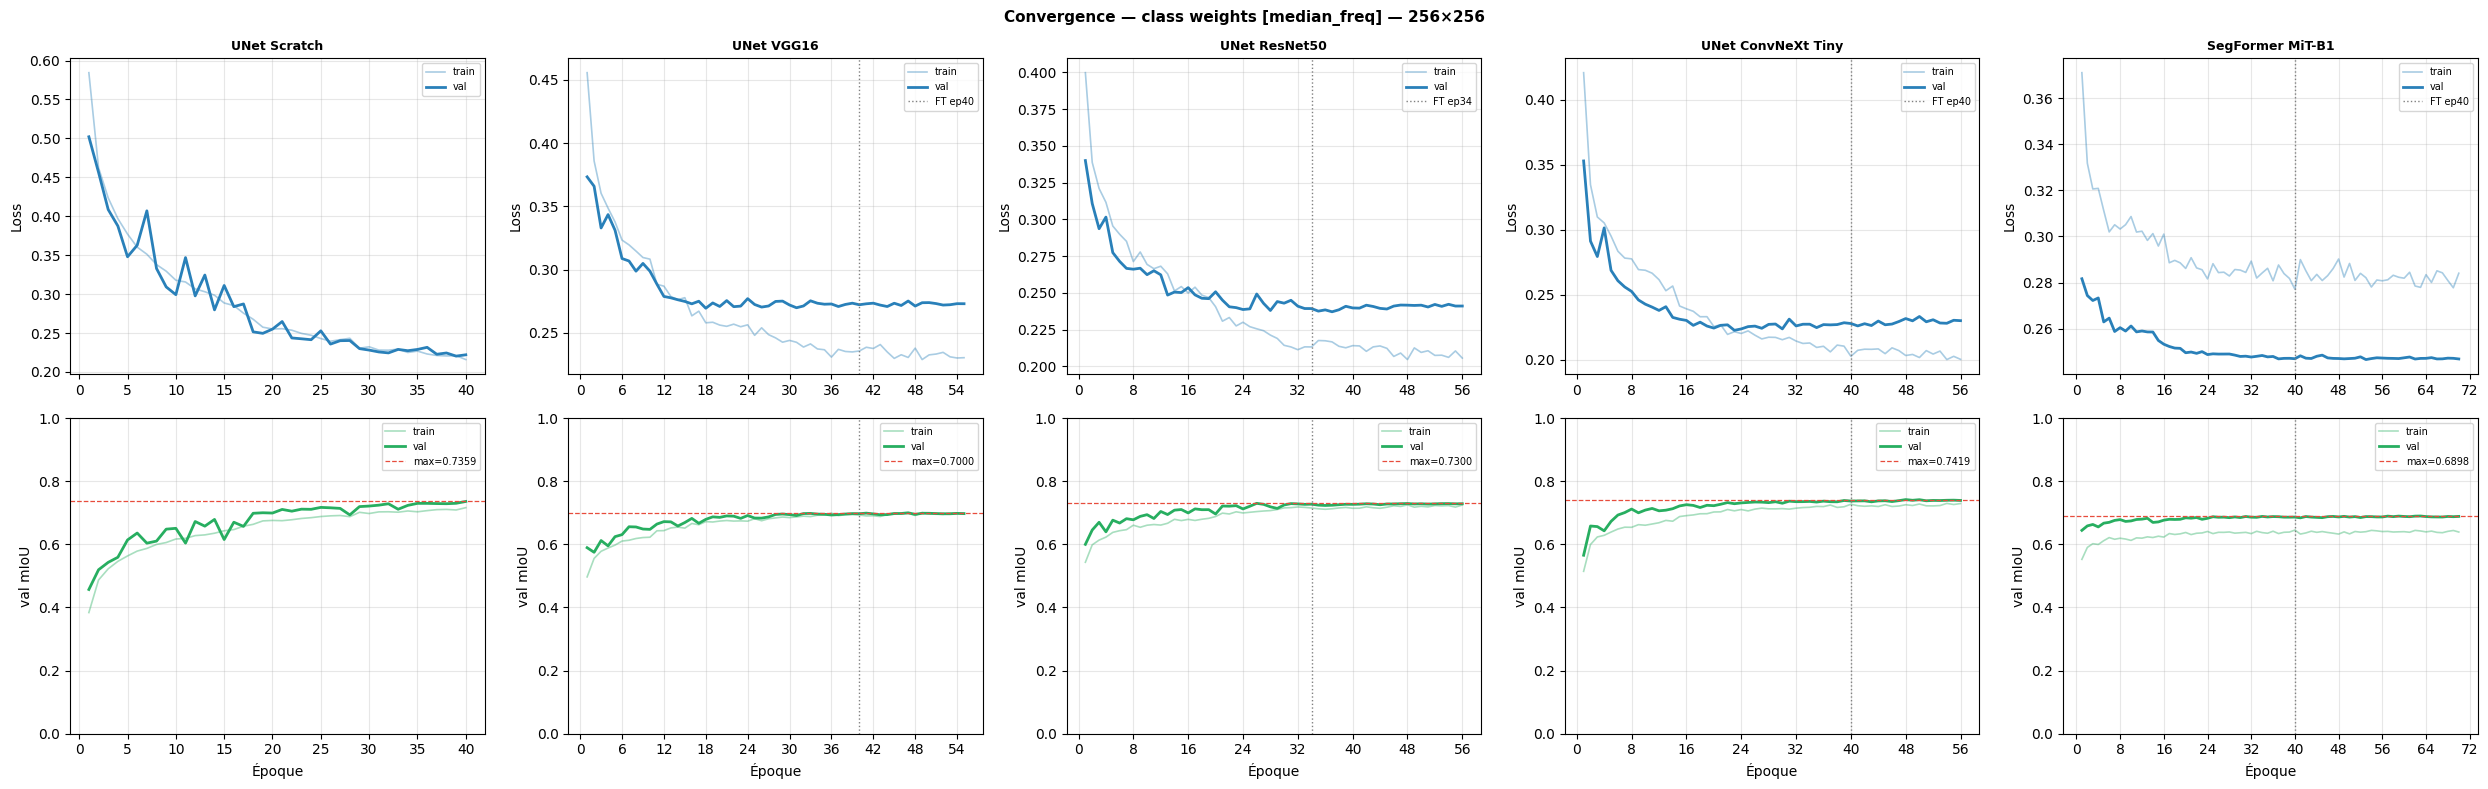

In [14]:
n   = len(results)
if n == 0:
    print("Aucun résultat à afficher.")
else:
    fig, axes = plt.subplots(2, n, figsize=(5*n, 8))
    if n == 1: axes = axes.reshape(2, 1)

    for j, (mname, r) in enumerate(results.items()):
        hist = r["history"]
        ep   = range(1, len(hist["val_mIoU"]) + 1)
        sp   = r["ep_ph1"]

        ax = axes[0][j]
        ax.plot(ep, hist.get("loss",     []), color="#2980b9", alpha=0.4, lw=1.2, label="train")
        ax.plot(ep, hist.get("val_loss", []), color="#2980b9", lw=2,               label="val")
        if 0 < sp < len(list(ep)):
            ax.axvline(sp, color="grey", linestyle=":", lw=1, label=f"FT ep{sp}")
        ax.set_title(LABELS.get(mname, mname), fontsize=9, fontweight="bold")
        ax.set_ylabel("Loss"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

        ax = axes[1][j]
        ax.plot(ep, hist.get("mIoU",     []), color="#27ae60", alpha=0.4, lw=1.2, label="train")
        ax.plot(ep, hist.get("val_mIoU", []), color="#27ae60", lw=2,               label="val")
        if 0 < sp < len(list(ep)):
            ax.axvline(sp, color="grey", linestyle=":", lw=1)
        best = max(hist["val_mIoU"])
        ax.axhline(best, color="#e74c3c", linestyle="--", lw=0.9, label=f"max={best:.4f}")
        ax.set_ylim(0, 1); ax.set_ylabel("val mIoU")
        ax.set_xlabel("Époque"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    plt.suptitle(f"Convergence — class weights [{WEIGHT_MODE}] — 256×256",
                 fontweight="bold", fontsize=11)
    plt.tight_layout()
    plt.savefig(str(EXP_DIR / "nb10_convergence.png"), dpi=130, bbox_inches="tight")
    plt.show()


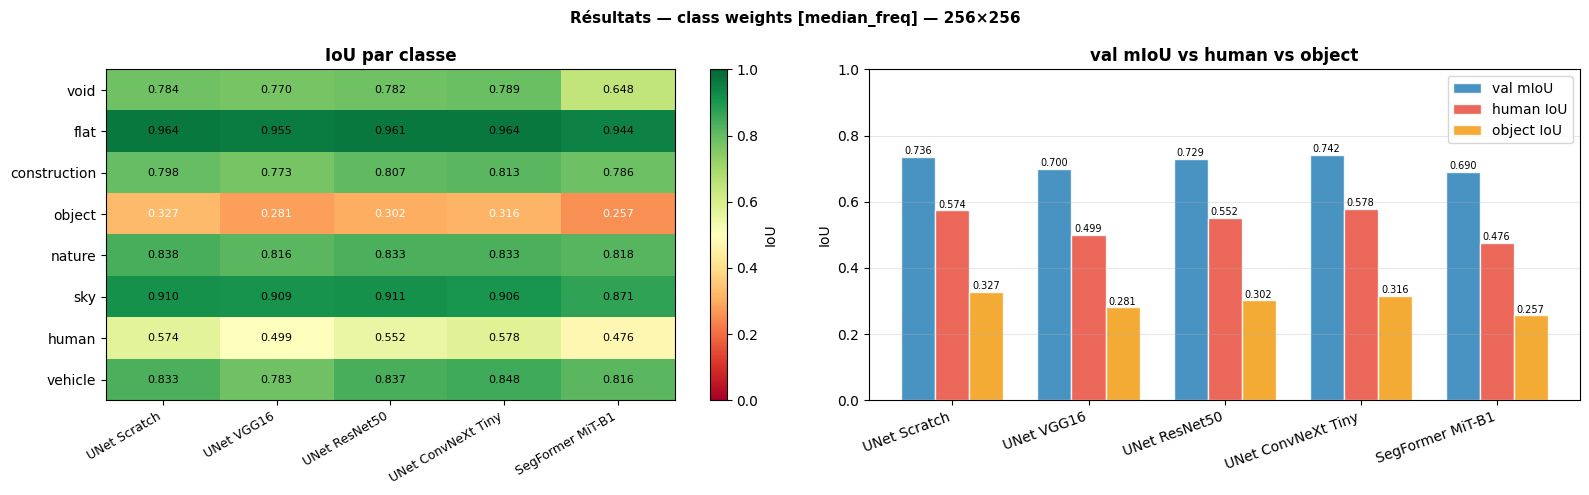

In [15]:
if results:
    models_ok  = list(results.keys())
    labels_ok  = [LABELS.get(m, m) for m in models_ok]
    colors_cls = [tuple(c/255 for c in PALETTE[i]) for i in range(N_CLASSES)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Heatmap IoU par classe
    data = {LABELS.get(m,m): [results[m]["per_class_iou"][c] for c in CATEGORY_NAMES]
            for m in models_ok}
    df_h = pd.DataFrame(data, index=CATEGORY_NAMES)
    im   = axes[0].imshow(df_h.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    axes[0].set_xticks(range(len(df_h.columns)))
    axes[0].set_xticklabels(df_h.columns, rotation=30, ha="right", fontsize=9)
    axes[0].set_yticks(range(N_CLASSES)); axes[0].set_yticklabels(CATEGORY_NAMES)
    for i in range(N_CLASSES):
        for j in range(len(df_h.columns)):
            v = df_h.iloc[i, j]
            axes[0].text(j, i, f"{v:.3f}", ha="center", va="center",
                         fontsize=8, color="black" if v > 0.35 else "white")
    plt.colorbar(im, ax=axes[0], label="IoU")
    axes[0].set_title("IoU par classe", fontweight="bold")

    # Barplot val mIoU / human / object
    x = np.arange(len(labels_ok)); w = 0.25
    for i, (label, color, key) in enumerate([
        ("val mIoU",   "#2980b9", None),
        ("human IoU",  "#e74c3c", "human"),
        ("object IoU", "#f39c12", "object"),
    ]):
        vals = [results[m]["val_mIoU"] if key is None
                else results[m]["per_class_iou"][key] for m in models_ok]
        bars = axes[1].bar(x+(i-1)*w, vals, w, label=label,
                           color=color, edgecolor="white", alpha=0.85)
        for bar, v in zip(bars, vals):
            axes[1].text(bar.get_x()+bar.get_width()/2, v+0.008,
                         f"{v:.3f}", ha="center", fontsize=7)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels_ok, rotation=20, ha="right")
    axes[1].set_ylim(0, 1); axes[1].set_ylabel("IoU")
    axes[1].set_title("val mIoU vs human vs object", fontweight="bold")
    axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)

    plt.suptitle(f"Résultats — class weights [{WEIGHT_MODE}] — 256×256",
                 fontweight="bold", fontsize=11)
    plt.tight_layout()
    plt.savefig(str(EXP_DIR / "nb10_results.png"), dpi=150, bbox_inches="tight")
    plt.show()


In [16]:
if results:
    summary = {
        "weight_mode"   : WEIGHT_MODE,
        "class_weights" : {CATEGORY_NAMES[i]: round(float(class_weights[i]), 4)
                           for i in range(N_CLASSES)},
        "pixel_freq_pct": {CATEGORY_NAMES[i]: round(float(frequencies[i]*100), 3)
                           for i in range(N_CLASSES)},
        "results"       : {m: {
            "val_loss"      : r["val_loss"],
            "val_mIoU"      : r["val_mIoU"],
            "test_mIoU"     : r["test_mIoU"],
            "per_class_iou" : r["per_class_iou"],
            "train_time_min": r["train_time_min"],
        } for m, r in results.items()},
    }
    out_path = EXP_DIR / "nb10_summary.json"
    out_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False))
    print(f"Résumé sauvegardé → {out_path}")


Résumé sauvegardé → /home/ui/PROJ9/out/experiments/nb10_summary.json
